In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

##########데이터 로드

train_df = pd.read_excel('https://github.com/cranberryai/todak_todak_python/blob/master/machine_learning/regression/%E1%84%82%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%87%E1%85%A5TV%E1%84%80%E1%85%A1%E1%84%80%E1%85%A7%E1%86%A8_%E1%84%8E%E1%85%AC%E1%84%8C%E1%85%A9%E1%86%BC.xlsx?raw=true', sheet_name='train')
test_df = pd.read_excel('https://github.com/cranberryai/todak_todak_python/blob/master/machine_learning/regression/%E1%84%82%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%87%E1%85%A5TV%E1%84%80%E1%85%A1%E1%84%80%E1%85%A7%E1%86%A8_%E1%84%8E%E1%85%AC%E1%84%8C%E1%85%A9%E1%86%BC.xlsx?raw=true', sheet_name='test')



In [5]:
train_df.shape, test_df.shape

((7000, 12), (3000, 12))

In [6]:
search_df = train_df[(train_df['LCD']==0) & (train_df['LED']==0) & (train_df['OLED']==0) & (train_df['QLED']==0)]
train_df = train_df.drop(search_df.index,axis=0)
search_df = test_df[(test_df['LCD']==0) & (test_df['LED']==0) & (test_df['OLED']==0) & (test_df['QLED']==0)]
test_df = test_df.drop(search_df.index, axis=0)
train_df.shape, test_df.shape

((6636, 12), (2816, 12))

In [7]:
train_df.head()

,ID,판매가,화면크기,형태,해상도,화면비율,LCD,LED,OLED,QLED,단자,부가기능
0,8,396240,55,0,2160,1,0,1,0,0,3,1
1,9,412870,55,0,2160,1,0,1,0,0,3,1
2,10,414590,55,0,2160,1,0,1,0,0,3,1
3,14,418000,55,0,2160,1,0,1,0,0,3,1
4,15,419000,55,0,2160,1,0,1,0,0,3,1


In [110]:
train_df.corr()

,ID,판매가,화면크기,형태,해상도,화면비율,LCD,LED,OLED,QLED,단자,부가기능
ID,1.000000,0.209871,0.059389,0.114880,-0.029099,0.120977,0.025500,-0.111327,0.122795,0.049296,0.002121,0.244514
판매가,0.209871,1.000000,0.634457,0.052178,0.370425,-0.150205,-0.008157,-0.487213,0.239198,0.415364,-0.214304,0.371879
화면크기,0.059389,0.634457,1.000000,0.111088,0.686708,-0.078878,0.007966,-0.263554,0.094148,0.243651,-0.156203,0.387837
형태,0.114880,0.052178,0.111088,1.000000,0.135387,-0.045618,-0.016548,-0.023764,-0.032282,0.049418,-0.067695,0.139098
해상도,-0.029099,0.370425,0.686708,0.135387,1.000000,-0.112418,-0.064289,-0.228817,0.087024,0.220796,-0.276793,0.347716
화면비율,0.120977,-0.150205,-0.078878,-0.045618,-0.112418,1.000000,-0.054632,0.184225,-0.024628,-0.186433,0.298510,0.309073
LCD,0.025500,-0.008157,0.007966,-0.016548,-0.064289,-0.054632,1.000000,-0.132428,-0.009634,-0.017244,0.053150,-0.079624
LED,-0.111327,-0.487213,-0.263554,-0.023764,-0.228817,0.184225,-0.132428,1.000000,-0.469097,-0.839599,0.277607,-0.152042
OLED,0.122795,0.239198,0.094148,-0.032282,0.087024,-0.024628,-0.009634,-0.469097,1.000000,-0.061083,-0.103933,0.072242
QLED,0.049296,0.415364,0.243651,0.049418,0.220796,-0.186433,-0.017244,-0.839599,-0.061083,1.000000,-0.264525,0.144511


In [86]:
####################
## 데이터의 갯수 확인, 스케일링 여부 때문에
###################
colList=train_df.columns[2:]
for tmp in colList:
    print(f'--->{tmp}')
    print(train_df[tmp].unique())

--->화면크기
[55 65 32 43 49 48 40 75 50 80 78 42 77 70 60 24 47 15]
--->형태
[0 1]
--->해상도
[2160  720 1080]
--->화면비율
[1 0]
--->LCD
[0 1]
--->LED
[1 0]
--->OLED
[0 1]
--->QLED
[0 1]
--->단자
[3 5 4 2 0 6 1]
--->부가기능
[1 7 3 0 2 4 8 5 6]


In [88]:
# 스케일링 적용 대상
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()  # 또는 StandardScaler() 선택
columns_to_scale = ['화면크기', '해상도', '단자', '부가기능']
data_scaled = train_df.copy()

data_scaled[columns_to_scale] = scaler.fit_transform(train_df[columns_to_scale])

data_scaled.head()

,ID,판매가,화면크기,형태,해상도,화면비율,LCD,LED,OLED,QLED,단자,부가기능
0,8,396240,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
1,9,412870,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
2,10,414590,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
3,14,418000,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
4,15,419000,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092


In [107]:
x_train = data_scaled.drop(['ID', '판매가'], axis=1)
x_test = data_scaled.drop(['ID', '판매가'], axis=1)
y_train = data_scaled['판매가']
y_test = data_scaled['판매가']

In [108]:
x_train.head()

,화면크기,형태,해상도,화면비율,LCD,LED,OLED,QLED,단자,부가기능
0,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
1,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
2,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
3,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092
4,0.15274,0,0.667767,1,0,1,0,0,0.112325,-1.040092


In [92]:
x_train = x_train.to_numpy()
x_test = x_test.to_numpy()

In [94]:
x_train[0]

array([ 0.15273977,  0.        ,  0.66776682,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.11232516, -1.04009221])

In [95]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train) # OLS에 의해서 w,b값이 생성
model.intercept_,model.coef_   # 화면크기*8611.46002+형태*19350.8804


(-1.0955711983042478e+19,
 array([ 1.04386427e+06, -1.97993620e+05, -3.95791274e+05, -4.03685054e+05,
         1.09557120e+19,  1.09557120e+19,  1.09557120e+19,  1.09557120e+19,
        -1.53186678e+05,  3.73537350e+05]))

In [97]:
# 독립 변수 이름
feature_names = train_df.columns[2:]
print(feature_names)

Index(['화면크기', '형태', '해상도', '화면비율', 'LCD', 'LED', 'OLED', 'QLED', '단자',
       '부가기능'],
      dtype='object')


In [98]:
# 회귀 계수 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

coef_df=pd.DataFrame(model.coef_ ,columns=['coef'])
coef_df.index=feature_names
coef_df.sort_values(by='coef', ascending=False)




,coef
OLED,1.095571e+19
QLED,1.095571e+19
LED,1.095571e+19
LCD,1.095571e+19
화면크기,1.043864e+06
부가기능,3.735374e+05
단자,-1.531867e+05
형태,-1.979936e+05
해상도,-3.957913e+05
화면비율,-4.036851e+05


In [99]:
##########모델 검증
print(model.score(x_test, y_test)) #0.5462414358589345

0.5675739076174033


In [100]:
# r2값등을 통해서 평가가능
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred=model.predict(x_test)

# 성능 평가
mse= mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'mse_scaled: {mse}')
print(f'rmse_scaled: {rmse}')
print(f'mae_scaled: {mae}')
print(f'r2_scaled: {r2}')

mse_scaled: 1267713235105.722
rmse_scaled: 1125927.721972295
mae_scaled: 619773.3223327305
r2_scaled: 0.5675739076174033


###############################
## ols로 평가
################################

In [105]:
import statsmodels.api as sm
c = sm.add_constant(x_train)  # X에 상수항 추가
model_ols = sm.OLS(y_train, X)  # OLS 회귀 모델 정의
results = model_ols.fit()  # 모델 학습
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    판매가   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     869.7
Date:                Mon, 16 Dec 2024   Prob (F-statistic):               0.00
Time:                        17:26:06   Log-Likelihood:            -1.0188e+05
No. Observations:                6636   AIC:                         2.038e+05
Df Residuals:                    6625   BIC:                         2.039e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.758e+16   2.44e+17      0.318      0.750      -4e+17    5.55e+17
x1          1.042e+06   1.98e+04     52.659      0.000       1e+06    1.08e+06
x2         -1.935e+05   4.89e+04     -3.955      0.000   -2.89e+05   -9.76e+04
x3          -3.93e+05      2e+04    -19.617      0.000   -4.32e+05   -3.54e+05
x4         -4.051e+05   3.14e+04    -12.903      0.000   -4.67e+05   -3.44e+05
x5         -7.758e+16   2.44e+17     -0.318      0.750   -5.55e+17       4e+17
x6         -7.758e+16   2.44e+17     -0.318      0.750   -5.55e+17       4e+17
x7         -7.758e+16   2.44e+17     -0.318      0.750   -5.55e+17       4e+17
x8         -7.758e+16   2.44e+17     -0.318      0.750   -5.55e+17       4e+17
x9         -1.535e+05   1.57e+04     -9.779      0.000   -1.84e+05   -1.23e+05
x10         3.715e+05    1.7e+04     21.872      0.000    3.38e+05    4.05e+05
==============================================================================
Omnibus:                     8941.314   Durbin-Watson:                   0.557
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3864077.848
Skew:                           7.427   Prob(JB):                         0.00
Kurtosis:                     120.279   Cond. No.                     5.84e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.28e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

####################
## xgboost
####################

In [19]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   - -------------------------------------- 6.0/124.9 MB 30.8 MB/s eta 0:00:04
   ---- ----------------------------------- 13.1/124.9 MB 30.4 MB/s eta 0:00:04
   ------- -------------------------------- 23.6/124.9 MB 37.3 MB/s eta 0:00:03
   ---------- ----------------------------- 34.3/124.9 MB 40.4 MB/s eta 0:00:03
   ------------- -------------------------- 42.7/124.9 MB 40.0 MB/s eta 0:00:03
   ---------------- ----------------------- 52.2/124.9 MB 40.5 MB/s eta 0:00:02
   ------------------ --------------------- 57.1/124.9 MB 38.3 MB/s eta 0:00:02
   --------------------- ------------------ 67.4/124.9 MB 39.4 MB/s eta 0:00:02
   ------------------------ --------------- 76.3/124.9 MB 39.6 MB/s eta 0:00:02
   -------------------------- ------------- 83.9/124.9 MB 39.1 MB/s eta 0:00:02
   ----------------------------- ---------- 91.8/124.9 MB 39.0 MB/s eta 0:00:01
   ------------------------------- -------- 99.4/1

In [70]:
# XGBoost 모델 초기화
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', seed=42)

# 하이퍼파라미터 그리드 서치
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(x_train, y_train)


Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [71]:
# 최적 하이퍼파라미터 확인
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [72]:
# 최적 모델로 예측 및 평가
best_model = grid_search.best_estimator_
y_pred_xgb = best_model.predict(x_test)

# 성능 평가
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'mse_xgb: {mse_xgb}')
print(f'rmse_xgb: {rmse_xgb}')
print(f'mae_xgb: {mae_xgb}')
print(f'r2_xgb: {r2_xgb}')


mse_xgb: 664094005119.843
rmse_xgb: 814919.6310801717
mae_xgb: 370663.29122092505
r2_xgb: 0.7712515592575073


<Figure size 1000x800 with 0 Axes>

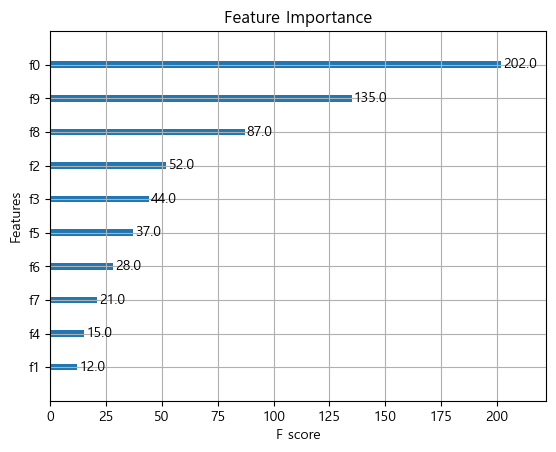

In [73]:
# 특성 중요도 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type='weight', title='Feature Importance')
plt.show()


In [74]:
train_df.head() # 이중 f0은 '화면크기'임

,ID,판매가,화면크기,형태,해상도,화면비율,LCD,LED,OLED,QLED,단자,부가기능
0,8,396240,55,0,2160,1,0,1,0,0,3,1
1,9,412870,55,0,2160,1,0,1,0,0,3,1
2,10,414590,55,0,2160,1,0,1,0,0,3,1
3,14,418000,55,0,2160,1,0,1,0,0,3,1
4,15,419000,55,0,2160,1,0,1,0,0,3,1


###############
## 모델 예측

In [32]:
##########모델 예측, 정규화 하지 않은 자료
# 화면크기	형태	해상도	화면비율	LCD	LED	OLED	QLED	단자	부가기능
new_x_test = np.array([
    [55, 0, 2160, 1, 0, 1, 0, 0, 3, 1]
])

y_predict = model.predict(new_x_test)
y_predict[0]
#print(y_predict[0]) #694212.0204504852




764228.6408461384

In [35]:
###################
## 정규화 한 자료일때는 (스케일링자료)
####################
new_x_test = np.array([[55, 0, 2160, 1, 0, 1, 0, 0, 3, 1]])
new_x_test_scaled = scaler.transform(new_x_test)
y_new_predict = best_model.predict(new_x_test_scaled)
print(f"Predicted Price: {y_new_predict[0]:.2f}")

Predicted Price: 407080.72
